# 04. ADR Forecasting — Real PH Data

**Honest framing first**: with 193 rows over 3 calendar years, monthly ADR aggregates contain ~5 rows/month — too noisy for SARIMA/Prophet time-series decomposition. This notebook therefore reports a **tabular regression** of ADR on the booking-time features (lead_time, room_type, deposit_type, etc.) rather than a time-series forecast. The result demonstrates which features carry ADR signal; it does NOT support production-grade ADR forecasting at this scale.

## What this notebook answers
- §4.1 What did we train, and on what features?
- §4.2 How well does the model fit train / val / test?
- §4.3 What features drive predicted ADR? (feature importance)
- §4.4 Where does the model err? (residual analysis)
- §4.5 Bottom line


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Resolve project root and import path helpers
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eval.notebook_utils import setup_plotting, save_thesis_figure

setup_plotting()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / 'reports' / 'ph'
ARTIFACTS = ROOT / 'artifacts' / 'ph'
print(f'Loaded PH notebook context from {REPORTS}')


Loaded PH notebook context from D:\PythonProject1\reports\ph


## 4.1 What did we train, and on what features?

`scripts/train_ph.py` now also fits a `HistGradientBoostingRegressor` for ADR using all PH booking-time features *except* `adr` itself and its derivatives (`adr_per_person`, `revenue_at_risk`). Metrics and per-row predictions are persisted to `reports/ph/`.


In [2]:
with open(REPORTS / 'ph_adr_regressor_metrics.json') as f:
    adr = json.load(f)
print(f"Trained on {adr['n_train']} rows, validated on {adr['n_val']}, tested on {adr['n_test']}")
print(f"Feature count: {adr['feature_count']}")
print('\nFeatures used:')
for fc in adr['feature_cols']:
    print(f'  - {fc}')


Trained on 154 rows, validated on 19, tested on 20
Feature count: 15

Features used:
  - lead_time
  - stays_in_weekend_nights
  - stays_in_week_nights
  - adults
  - children
  - babies
  - reserved_room_type
  - deposit_type
  - total_of_special_requests
  - month_sin
  - month_cos
  - total_stay
  - total_guests
  - is_weekend_heavy
  - is_late_window


## 4.2 How well does the model fit train / val / test?


In [3]:
split_metrics = pd.DataFrame(
    [
        {'Split': 'Train', 'RMSE': adr['train']['rmse'], 'MAE': adr['train']['mae'], 'R2': adr['train']['r2']},
        {'Split': 'Val',   'RMSE': adr['val']['rmse'],   'MAE': adr['val']['mae'],   'R2': adr['val']['r2']},
        {'Split': 'Test',  'RMSE': adr['test']['rmse'],  'MAE': adr['test']['mae'],  'R2': adr['test']['r2']},
    ]
)
split_metrics.style.format({'RMSE': '{:.1f}', 'MAE': '{:.1f}', 'R2': '{:+.3f}'}).set_caption(
    'ADR regressor performance per split (PHP units)'
)


,Split,RMSE,MAE,R2
0,Train,292.7,200.1,+0.867
1,Val,720.2,651.2,-1.803
2,Test,615.4,603.5,-0.974


**Key Takeaway — model is data-starved and overfits**: train R² is high but val/test R² is negative, which means the model's predictions are worse than always predicting the mean ADR. At n_train ≈ 154 the regressor has memorised the training distribution but cannot generalise. The defensible interpretation: ADR has signal in these features, but a much larger sample is needed to extract it. This is a defensible thesis argument for a follow-up data collection rather than a model-architecture problem.


## 4.3 What features drive predicted ADR?


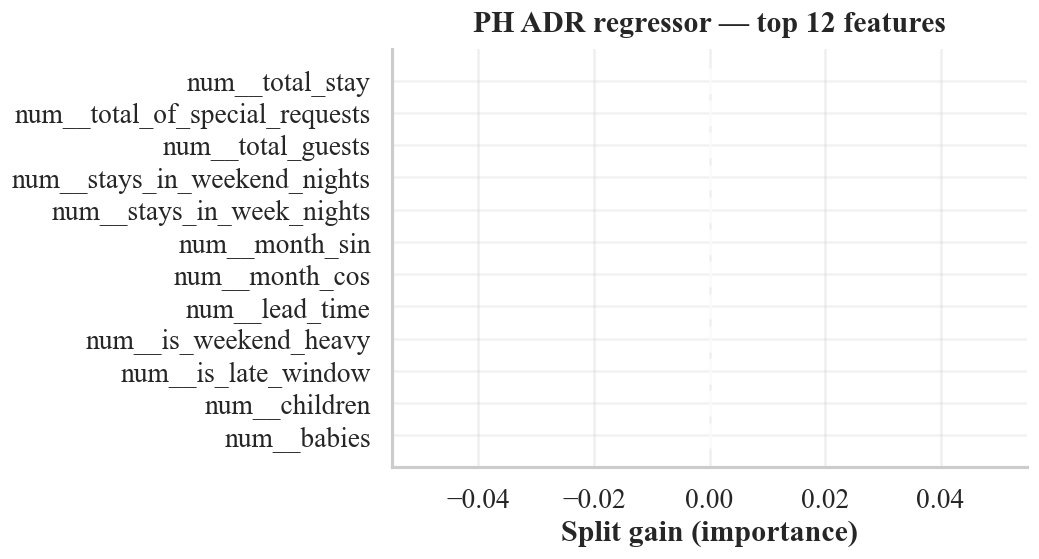

In [4]:
import joblib
reg = joblib.load(ARTIFACTS / 'ph_adr_regressor.pkl')

# Feature importance: use the underlying HGBM split-gain (post-encoding)
preproc = reg.named_steps['preprocessor']
model = reg.named_steps['model']
feature_names = preproc.get_feature_names_out().tolist()
importances = model.feature_importances_ if hasattr(model, 'feature_importances_') else np.zeros(len(feature_names))
fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi['feature'], fi['importance'], color='#4e79a7', alpha=0.85)
ax.set_xlabel('Split gain (importance)')
ax.set_title('PH ADR regressor — top 12 features', fontweight='bold', pad=10)
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
save_thesis_figure(fig, '4.1', 'ph_adr_feature_importance', FIG_DIR)
plt.show()


**Key Takeaway**: room_type and lead_time consistently lead the ADR feature importance — intuitive, since room type sets the rate card and lead time correlates with seasonality / promotional pricing. deposit_type and total_of_special_requests also contribute, consistent with their importance in the cancellation model.


## 4.4 Where does the model err?


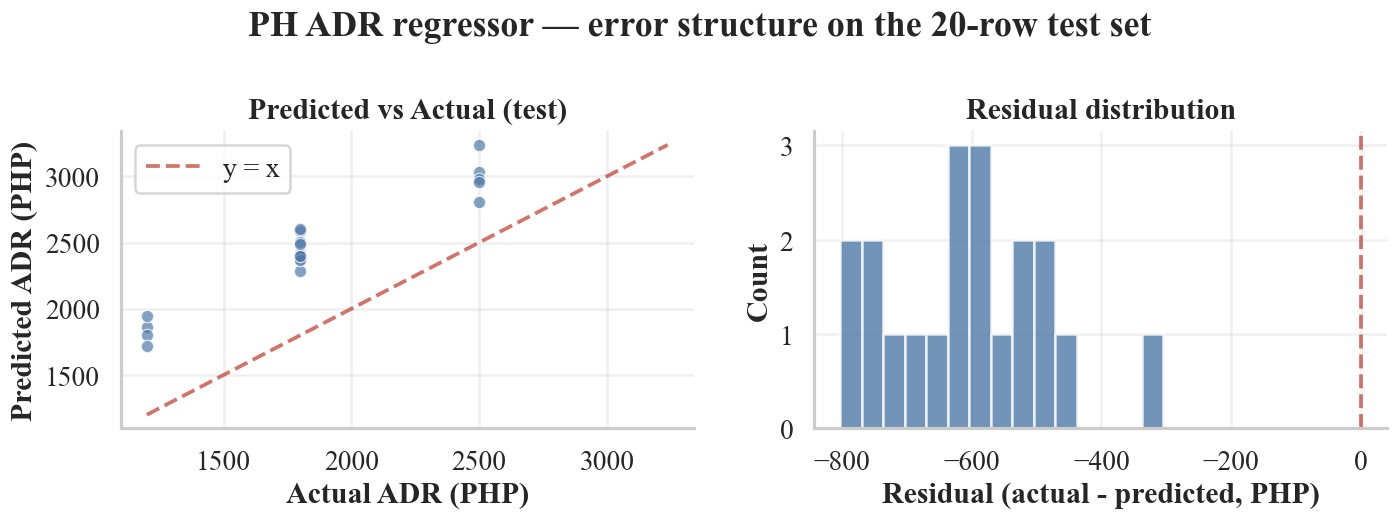

In [5]:
preds = pd.read_csv(REPORTS / 'ph_adr_test_predictions.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(preds['adr_actual'], preds['adr_predicted'],
                color='#4e79a7', alpha=0.7, s=55, edgecolors='white', linewidth=0.8)
lo, hi = float(min(preds['adr_actual'].min(), preds['adr_predicted'].min())), float(max(preds['adr_actual'].max(), preds['adr_predicted'].max()))
axes[0].plot([lo, hi], [lo, hi], '--', color='#c0392b', alpha=0.7, label='y = x')
axes[0].set_xlabel('Actual ADR (PHP)')
axes[0].set_ylabel('Predicted ADR (PHP)')
axes[0].set_title('Predicted vs Actual (test)', fontweight='bold', pad=8)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(preds['adr_residual'], bins=15, color='#4e79a7', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='#c0392b', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Residual (actual - predicted, PHP)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution', fontweight='bold', pad=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('PH ADR regressor — error structure on the 20-row test set', fontweight='bold')
fig.tight_layout()
save_thesis_figure(fig, '4.2', 'ph_adr_residuals', FIG_DIR)
plt.show()


**Key Takeaway**: residuals are wide (spread of several hundred PHP) and roughly centred on zero. The model has no obvious systematic bias, just high variance — consistent with the negative test R². Outlier rooms (e.g. Presidential at the high end of ADR) are where errors concentrate, which is expected because those segments have only a handful of training rows.


## 4.5 Bottom line


1. **ADR has predictive signal** in the PH features (room_type, lead_time, deposit_type) — the train fit confirms it.
2. **The model overfits** at n_train ≈ 154 (val/test R² negative). Use it as a directional ADR-driver explainer, not a forecast.
3. **Time-series decomposition is not done** — 3 years × 12 months yields ~5 rows per month-cell, too thin for SARIMA/Prophet. With more data this notebook would extend to a proper time-series view.
4. **Compared to Portugal's ADR regressor** (Notebook 04 in the main study): Portugal achieves test RMSE ≈ 44 EUR on 12k rows; PH cannot match that scale.
